In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Display first rows
print(df.head())

# -----------------------------
# 1. Check missing values
# -----------------------------
print("\nMissing values:")
print(df.isnull().sum())

# -----------------------------
# 2. Check duplicates
# -----------------------------
print("\nDuplicate rows:")
print(df.duplicated().sum())

# -----------------------------
# 3. Convert TotalCharges to numeric
# -----------------------------
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# -----------------------------
# 4. Encode categorical variables
# -----------------------------
le = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = le.fit_transform(df[column])

# -----------------------------
# 5. Normalize numerical features
# -----------------------------
scaler = StandardScaler()

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# -----------------------------
# 6. Save cleaned dataset
# -----------------------------
df.to_csv("cleaned_telco_churn.csv", index=False)

print("\nData cleaning and preprocessing completed!")

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

C:\Users\sanja\AppData\Local\Temp\ipykernel_26804\1011344473.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


Summary Statistics:
        customerID       gender  SeniorCitizen      Partner   Dependents  \
count  7043.000000  7043.000000    7043.000000  7043.000000  7043.000000   
mean   3521.000000     0.504756       0.162147     0.483033     0.299588   
std    2033.283305     0.500013       0.368612     0.499748     0.458110   
min       0.000000     0.000000       0.000000     0.000000     0.000000   
25%    1760.500000     0.000000       0.000000     0.000000     0.000000   
50%    3521.000000     1.000000       0.000000     0.000000     0.000000   
75%    5281.500000     1.000000       0.000000     1.000000     1.000000   
max    7042.000000     1.000000       1.000000     1.000000     1.000000   

             tenure  PhoneService  MultipleLines  InternetService  \
count  7.043000e+03   7043.000000    7043.000000      7043.000000   
mean  -1.916841e-17      0.903166       0.940508         0.872923   
std    1.000071e+00      0.295752       0.948554         0.737796   
min   -1.318165e+00

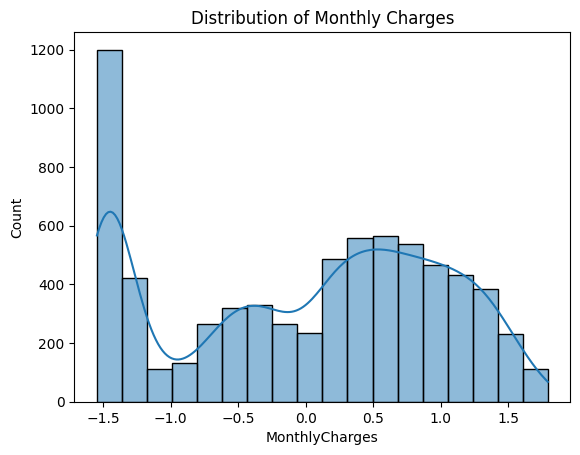

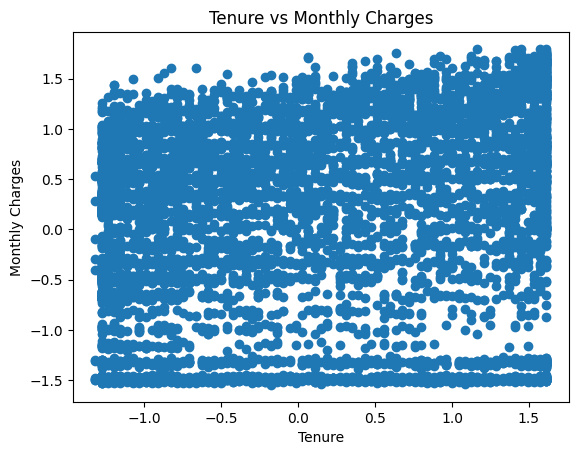

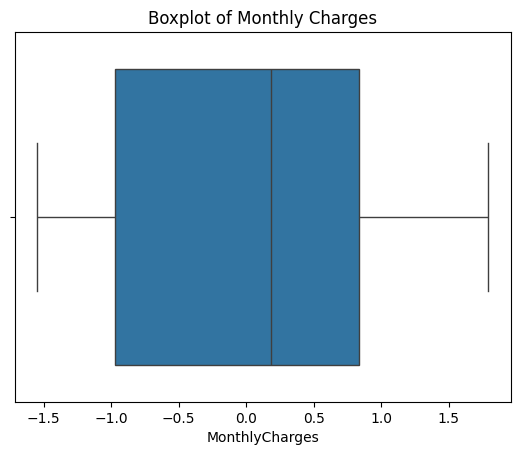

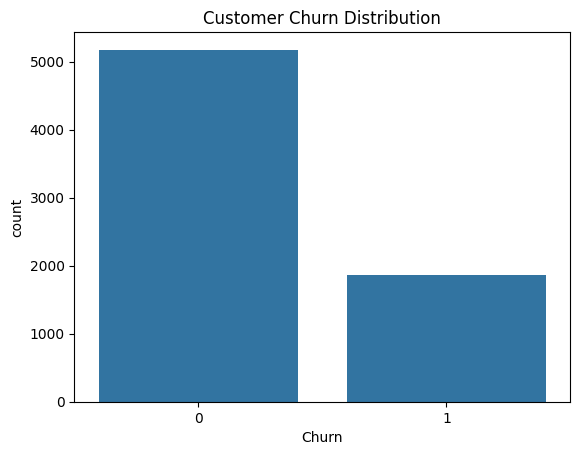

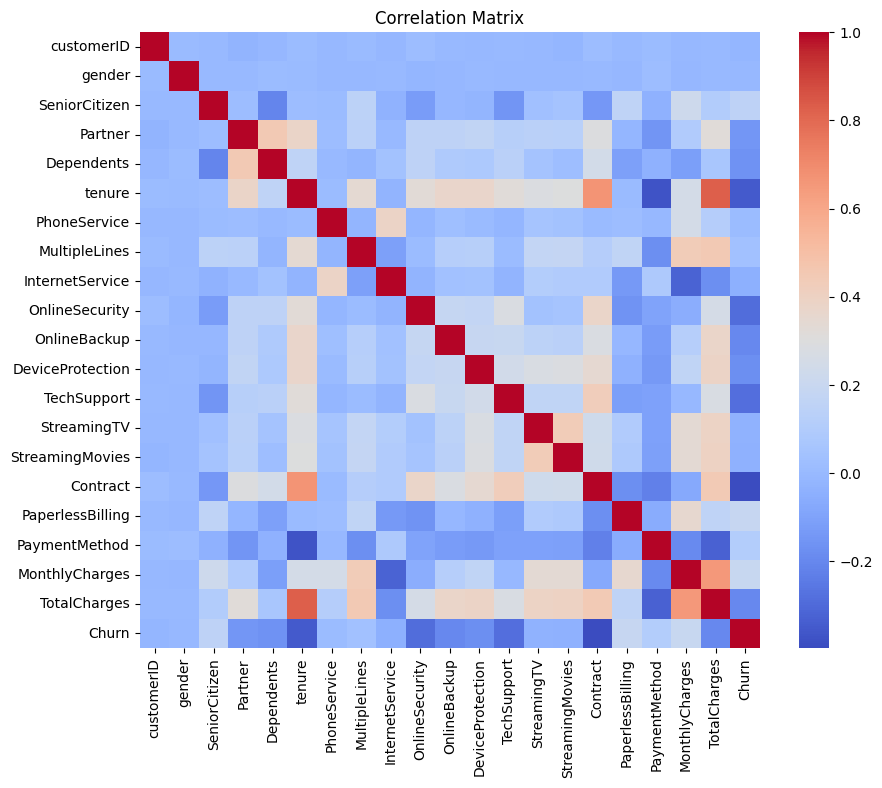

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("cleaned_telco_churn.csv")

# -----------------------------
# 1. Summary Statistics
# -----------------------------
print("Summary Statistics:")
print(df.describe())

# -----------------------------
# 2. Distribution of Monthly Charges
# -----------------------------
plt.figure()
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

# -----------------------------
# 3. Tenure vs Monthly Charges
# -----------------------------
plt.figure()
plt.scatter(df["tenure"], df["MonthlyCharges"])
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.title("Tenure vs Monthly Charges")
plt.show()

# -----------------------------
# 4. Boxplot for Monthly Charges
# -----------------------------
plt.figure()
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Boxplot of Monthly Charges")
plt.show()

# -----------------------------
# 5. Churn Distribution
# -----------------------------
plt.figure()
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

# -----------------------------
# 6. Correlation Matrix
# -----------------------------
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()